In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from data_pipeline import extrair_telemetria_piloto
from model_pipeline import treinar_modelo_adaboost

print("Extraindo telemetria...")
dados_historicos = extrair_telemetria_piloto(2024, 'Bahrain', 'VER')

# 3. Separando X e y e Treinando o modelo na memória
y_train = dados_historicos['LapTime']
X_train = dados_historicos.drop(columns=['LapTime'])

print("Treinando o modelo...")
modelo_dinamico = treinar_modelo_adaboost(X_train, y_train)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]


req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Extraindo telemetria...


req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


Treinando o modelo...


In [17]:


def simular_estrategia(modelo, colunas_X, total_voltas=30, composto_ativo='Compound_INTERMEDIATE'):
    dados_simulados = {
        'LapNumber' : list(range(1, total_voltas + 1)),
        'Stint' : [1.0] * total_voltas,
        'TyreLife' : list(range(1, total_voltas + 1))
    }

    for col in colunas_X:
        if col.startswith('Compound_'):
            dados_simulados[col] = [1 if col == composto_ativo else 0] * total_voltas

    df_simulacao = pd.DataFrame(dados_simulados)[colunas_X]
    df_simulacao['Tempo_Previsto'] = modelo.predict(df_simulacao)

    df_simulacao['Delta_Tempo'] = df_simulacao['Tempo_Previsto'].diff().fillna(0) 

    voltas_validas = df_simulacao[df_simulacao['TyreLife'] > 5]

    linha_cliff = voltas_validas.loc[voltas_validas['Delta_Tempo'].idxmax()]

    volta_cliff = int(linha_cliff['LapNumber'])
    perda_tempo = linha_cliff['Delta_Tempo']

    return df_simulacao, volta_cliff, perda_tempo # Reordena as colunas para corresponder ao conjunto de treinamento


In [18]:
df_pista, volta_cliff, perda_tempo = simular_estrategia(
    modelo = modelo_dinamico, 
    colunas_X = X_train.columns,  
    total_voltas = 30, 
    composto_ativo = 'Compound_SOFT'
)

#imprimir relatorio 

print("=" * 45)
print("      RELATÓRIO DE ESTRATÉGIA DE CORRIDA      ")
print("=" * 45)
print(f"• Ponto de 'Cliff' detectado: Volta {volta_cliff}")
print(f"• Perda de ritmo estimada: +{perda_tempo:.3f}s")
print(f"• JANELA IDEAL DE PIT STOP: Voltas {volta_cliff - 1} a {volta_cliff}")
print("=" * 45)

      RELATÓRIO DE ESTRATÉGIA DE CORRIDA      
• Ponto de 'Cliff' detectado: Volta 7
• Perda de ritmo estimada: +0.092s
• JANELA IDEAL DE PIT STOP: Voltas 6 a 7


,LapNumber,Stint,TyreLife,Compound_HARD,Compound_SOFT,Compound_MEDIUM,Compound_INTERMEDIATE,Compound_WET,Tempo_Previsto,Delta_Tempo
0,1,1.0,1,0,1,0,0,0,95.283,0.000
1,2,1.0,2,0,1,0,0,0,95.283,0.000
2,3,1.0,3,0,1,0,0,0,96.700,1.417
3,4,1.0,4,0,1,0,0,0,96.700,0.000
4,5,1.0,5,0,1,0,0,0,96.700,0.000


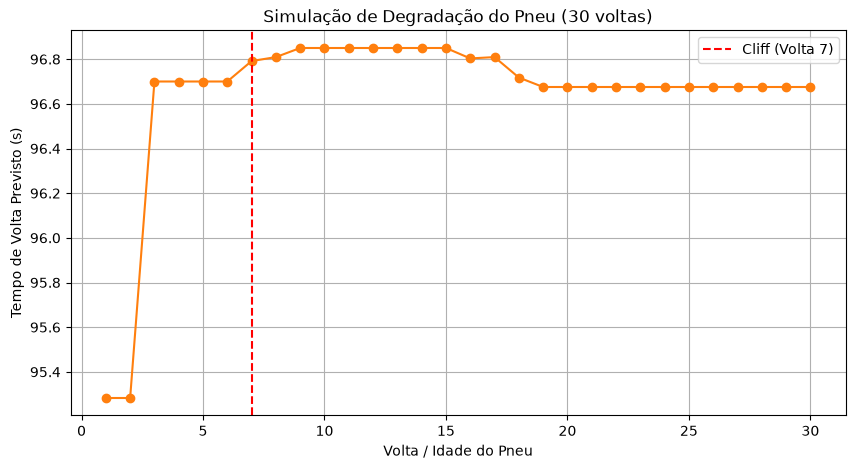

In [19]:

display(df_pista.head())

plt.figure(figsize=(10, 5))
plt.plot(df_pista['LapNumber'], df_pista['Tempo_Previsto'], marker='o', color='#ff7f0e')
plt.axvline(x=volta_cliff, color='red', linestyle='--', label=f'Cliff (Volta {volta_cliff})')
plt.title('Simulação de Degradação do Pneu (30 voltas)')
plt.xlabel('Volta / Idade do Pneu')
plt.ylabel('Tempo de Volta Previsto (s)')
plt.legend()
plt.grid(True)
plt.show()